In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[1]
sys.path.append(str(project_root))

import numpy as np
import torch
import matplotlib.pyplot as plt

from pinn.physics.lindblad_1q import LindbladSolver1Q

In [2]:
psi0 = np.array([1, 1], dtype=complex)
psi0 /= np.linalg.norm(psi0)

psi0 = torch.tensor(psi0, dtype=torch.complex64)

rho0 = torch.outer(psi0, psi0.conj()).unsqueeze(0)

print(rho0)
print(rho0.shape)

tensor([[[0.5000+0.j, 0.5000+0.j],
         [0.5000+0.j, 0.5000+0.j]]])
torch.Size([1, 2, 2])


In [3]:
solver = LindbladSolver1Q(
    t1=100,
    t2=100,
    dt=1
)

times, states = solver.run_simulation(
    rho0=rho0,
    time=200
)

print(times.shape)
print(states.shape)

(201,)
(201, 1, 2, 2)


In [4]:
states_np = states[:, 0, :, :]

rho00 = np.real(states_np[:, 0, 0])
rho11 = np.real(states_np[:, 1, 1])
rho01 = np.abs(states_np[:, 0, 1])

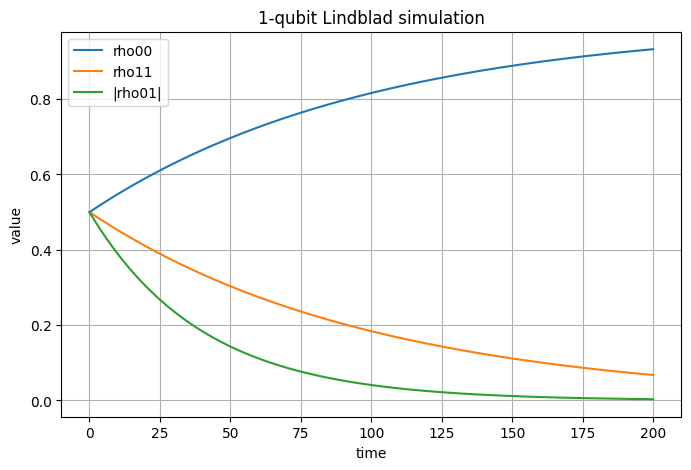

In [7]:
from pinn.utils.plotting import plot_1q_trajectory
plot_1q_trajectory(times, states)

In [10]:
import pinn.training.nn_solver_1q as nn_solver_1q

dir(nn_solver_1q)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__']